# traing autoencoder on benign only

In [ ]:
import time
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tqdm import tqdm
import dask.dataframe as dd
from sklearn.preprocessing import MinMaxScaler
import copy
from scipy import stats
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, auc
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import joblib
import pandas as pd
import joblib
import random
# Dataset & Model
class NumericDataset(Dataset):
    def __init__(self, data):
        self.data = torch.tensor(data, dtype=torch.float32)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.data[idx]
# Load and Preprocess Data

random.seed(42)  # set seed once outside
df_big = pd.read_csv("/kaggle/input/datasets/youssefnassar4/um-nids-benign-of-cic-ids2017-and-all-attack/all_attack_and_benign.csv")
df_big = df_big[df_big["label"] == "BENIGN"]  # filter rows where label is benign
df_big=df_big.drop(columns=['label'])
scaler = MinMaxScaler()   #Scale the data to avoid sensitvity to outliers
df_big = scaler.fit_transform(df_big)
df_big=df_big
# Save the fitted scaler for future use
joblib.dump(scaler, "#base_MLP_scaler.pkl")
#/////////////////////////////////////////////////////////////////////////////
#n_samples = int(1 * len(df_big))
#rng = np.random.default_rng(seed=42)   # reproducible like pandas' random_state
#idx = rng.choice(len(df_big), size=n_samples, replace=False)
df = df_big#df_big[idx] #Use only 10 percent

X_train, X_test = train_test_split(df, test_size=0.2, random_state=42)
#  Training Setup
train_dataset = NumericDataset(X_train)
test_dataset = NumericDataset(X_test)
g = torch.Generator()
g.manual_seed(42)
train_loader = DataLoader(train_dataset, batch_size=1880, shuffle=True,generator=g)
test_loader = DataLoader(test_dataset, batch_size=1280, shuffle=False)




class ImprovedAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super(ImprovedAutoencoder, self).__init__()
        bottleneck_dim = 4#max(8, input_dim // 6)

        self.encoder = nn.Sequential(
            nn.Linear(88, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(128, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(32, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(32, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(16, 16)
        )

        self.decoder = nn.Sequential(
            nn.Linear(16, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(16, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(32, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(32, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(32, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(128, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(512, 88)

        )


    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded
# Huber loss is more stable
def robust_loss(output, target, delta=1.0):
    residual = torch.abs(output - target)
    return torch.where(
        residual < delta,
        0.5 * residual**2,
        delta * residual - 0.5 * delta**2
    ).mean()
#  Training Setup
train_dataset = NumericDataset(X_train)
test_dataset = NumericDataset(X_test)
g = torch.Generator()
g.manual_seed(42)
train_loader = DataLoader(train_dataset, batch_size=1882, shuffle=True,generator=g)
test_loader = DataLoader(test_dataset, batch_size=1280, shuffle=False)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)

model = ImprovedAutoencoder(input_dim=76).to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

NUM_EPOCHS = 10
train_losses = []
eval_losses = []
best_eval=99999999
patience=3
bad=0
best_model=None
#  Training Loop
for epoch in range(NUM_EPOCHS):
    #time.sleep(0.02)
    model.train()
    total_train_loss = 0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", leave=False)
    for batch_x, _ in loop:

        batch_x = batch_x.to(device)
        output = model(batch_x)
        loss = robust_loss(output, batch_x)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Evaluation
    model.eval()
    total_eval_loss = 0
    with torch.no_grad():
        for batch_x, _ in test_loader:
            batch_x = batch_x.to(device)
            output = model(batch_x)
            loss = criterion(output, batch_x)
            total_eval_loss += loss.item()
    avg_eval_loss = total_eval_loss / len(test_loader)
    eval_losses.append(avg_eval_loss)
    if avg_eval_loss<best_eval :
        print("yay")
        best_eval=avg_eval_loss
        best_model = copy.deepcopy(model.state_dict())
        bad=0
    else:
        bad+=1
    if bad>=patience:
        break


    print(f"Epoch {epoch+1}/{NUM_EPOCHS}, Train Loss: {avg_train_loss:.4f}, Eval Loss: {avg_eval_loss:.4f}")




#  Final Evaluation


model.eval()
reconstruction_errors = []
num=0
with torch.no_grad():
    for batch_x, _ in tqdm(test_loader, desc="Evaluating"):
        num+= 1
        batch_x = batch_x.to(device)
        output = model(batch_x)
        loss = criterion(output,batch_x) # MSE
        reconstruction_errors.append(loss.cpu().numpy())
reconstruction_errors = np.array(reconstruction_errors)
print("number of batches:",num)

# Threshold from benign (test) distribution
threshold = np.percentile(reconstruction_errors, 94)


mean_error = reconstruction_errors.mean()

# Classify anomalies (all benign here that are anomalies are actually false positives)
anomalies = reconstruction_errors > threshold
false_positives = anomalies.sum()

# Print results
print(f"Mean reconstruction error: {mean_error:.6f}")
print(f"Anomaly threshold (99th percentile): {threshold:.6f}")
print(f"False positives: {round(false_positives/len(anomalies)* 100)}% out of {len(anomalies)} samples")




print(f"Detected {anomalies.sum()} anomalies out of {len(anomalies)} samples")

#  Save Model
torch.save(best_model, 'mlp_best_numeric_autoencoder.pth')


epochs = range(1, len(train_losses) + 1)

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, eval_losses, label='Eval Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Evaluation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#  Plot 2: Reconstruction Errors
joblib.dump(reconstruction_errors, "all_error")
plt.figure(figsize=(8, 5))
plt.hist(reconstruction_errors, bins=100, color='skyblue', alpha=0.8)
plt.axvline(threshold, color='red', linestyle='--', label=f"Threshold = {threshold:.3f}")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Reconstruction Errors")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
# Mean and Std reconstruction error
mean_error = reconstruction_errors.mean()
std_error = reconstruction_errors.std()
print(f"Mean reconstruction error: {mean_error:.6f}")
print(f"Std reconstruction error:  {std_error:.6f}")
print(f"Anomaly threshold (95th percentile): {threshold:.6f}")

print(f"False positives: {round(false_positives/len(anomalies)*100)}% out of {len(anomalies)} samples")

#///////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////
#///////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////
print("testing for fp/////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////")
#testing for fp:
#testing for fp:
fp_rate=0
#df = pd.read_csv('/content/benign-no-label/benign_no_label.csv')




#df.to_csv('attack_no_label2.csv', index=False)


#  Load and Preprocess Malicious & Benign Data

full_benign = df_big


#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.eval()
full_benign_loader = DataLoader(NumericDataset(full_benign), batch_size=128, shuffle=False)

#  Get Reconstruction Errors

def get_reconstruction_errors(loader):
        errors = []
        with torch.no_grad():
            for batch_x, _ in(loader):
                batch_x = batch_x.to(device)
                output = model(batch_x)

                loss = torch.mean((output - batch_x)**2, dim=1)
                errors.extend(loss.cpu().numpy())
        return np.array(errors)


benign_errors = reconstruction_errors
malicious_errors = get_reconstruction_errors(full_benign_loader)#malicous as in its benign but unseen

#  Threshold and Classification
threshold = np.percentile(benign_errors, 94)

benign_preds = benign_errors >threshold
malicious_preds=malicious_errors >threshold

# Metrics
tp = np.sum(malicious_preds)
fp = np.sum(benign_preds)
fn = len(malicious_errors) - tp
tn = len(benign_errors) - fp

precision = tp / (tp + fp + 1e-8)
recall = tp / (tp + fn + 1e-8)
f1 = 2 * precision * recall / (precision + recall + 1e-8)
accuracy = (tp + tn) / (len(benign_errors) + len(malicious_errors))



fp_rate=recall
print(f"false positve rate:{fp_rate}")

#//////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////
#////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////
print("actual testing/////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////")
# ===== ATTACK TESTING =====
from imblearn.over_sampling import SMOTE

df_all =pd.read_csv("/kaggle/input/datasets/youssefnassar4/um-nids-benign-of-cic-ids2017-and-all-attack/all_attack_and_benign.csv")
df_attack = df_all.copy()

# ── keep 10 % of benign, all attacks ──────────────────────────
benign_mask = df_attack["label"] == "BENIGN"
df_attack = pd.concat([df_attack[benign_mask].sample(frac=0.1, random_state=42),
                       df_attack[~benign_mask]])
labels = df_attack["label"].values

df_attack = df_attack.drop(columns=["label"])
df_attack = df_attack.replace([np.inf, -np.inf], np.nan).dropna()
df_attack = df_attack.select_dtypes(include='number')
labels = labels[:len(df_attack)]

sm = SMOTE(random_state=42)
df_attack_resampled, labels_resampled = df_attack,labels#sm.fit_resample(df_attack, labels)

malicious_scaled = scaler.transform(df_attack_resampled)
malicious_loader = DataLoader(NumericDataset(malicious_scaled), batch_size=128, shuffle=False)

malicious_errors = get_reconstruction_errors(malicious_loader)

threshold = np.percentile(benign_errors, 94)

y_true = labels_resampled
#y_true = labels
y_pred = np.where(malicious_errors > threshold, labels_resampled, "BENIGN")
#y_pred = np.where(malicious_errors > threshold, labels, "benign")
all_classes = sorted(np.unique(labels_resampled).tolist())  # remove "benign" from classes
#all_classes = sorted(np.unique(labels).tolist())  # remove "benign" from classes

print(classification_report(y_true, y_pred, labels=all_classes, digits=4))

cm = confusion_matrix(y_true, y_pred, labels=all_classes)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=all_classes, yticklabels=all_classes)
plt.title("Confusion Matrix — Per Attack Type (SMOTE)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

#  create the description column that will contain textual description of the network flows

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("/kaggle/input/datasets/youssefnassar4/um-nids-benign-of-cic-ids2017-and-all-attack/all_attack_and_benign.csv")

# ── DESCRIPTOR MAP ─────────────────────────────────────────────────────────────
# Triplets are (low, mid, high) based on the TRUE meaning of each NFStream column
# Sources: https://www.nfstream.org/docs/api (NFlow Core + Post-Mortem Statistical Features)
DESCRIPTORS = {

    # ── DURATION (ms): how long the flow was alive ───────────────────────────
    # low = short-lived bursts, high = persistent long connections
    "bidirectional_duration_ms":              ("transient",        "sustained",         "persistent"),
    "src2dst_duration_ms":                    ("transient",        "sustained",         "persistent"),
    "dst2src_duration_ms":                    ("transient",        "sustained",         "persistent"),

    # ── PACKET ACCUMULATORS: total packets exchanged ─────────────────────────
    # low = few packets (control/scan traffic), high = heavy exchange
    "bidirectional_packets":                  ("sparse",           "moderate",          "voluminous"),
    "src2dst_packets":                        ("sparse",           "moderate",          "voluminous"),
    "dst2src_packets":                        ("sparse",           "moderate",          "voluminous"),

    # ── BYTE ACCUMULATORS: total bytes transferred ───────────────────────────
    # low = lightweight (control msgs), high = bulk/data-heavy
    "bidirectional_bytes":                    ("lightweight",      "moderate",          "data-intensive"),
    "src2dst_bytes":                          ("lightweight",      "moderate",          "data-intensive"),
    "dst2src_bytes":                          ("lightweight",      "moderate",          "data-intensive"),

    # ── PACKET SIZE — MIN (ps): smallest packet observed in flow ─────────────
    # low min = tiny ACK-only or probe packets present
    # high min = even smallest packets were large (bulk/streaming)
    "bidirectional_min_ps":                   ("probe-sized",      "control-sized",     "payload-sized"),
    "src2dst_min_ps":                         ("probe-sized",      "control-sized",     "payload-sized"),
    "dst2src_min_ps":                         ("probe-sized",      "control-sized",     "payload-sized"),

    # ── PACKET SIZE — MEAN (ps): average packet size ─────────────────────────
    # low = mostly small/control packets (ACKs, DNS queries)
    # high = large average = bulk transfer / video / file download
    "bidirectional_mean_ps":                  ("control-dominated","mixed-payload",     "bulk-payload"),
    "src2dst_mean_ps":                        ("control-dominated","mixed-payload",     "bulk-payload"),
    "dst2src_mean_ps":                        ("control-dominated","mixed-payload",     "bulk-payload"),

    # ── PACKET SIZE — STDDEV (ps): variability in packet sizes ───────────────
    # low stddev = uniform sizes (streaming, VoIP, tunnels)
    # high stddev = mixed small+large packets (web browsing, mixed traffic)
    "bidirectional_stddev_ps":                ("uniform",          "mixed",             "heterogeneous"),
    "src2dst_stddev_ps":                      ("uniform",          "mixed",             "heterogeneous"),
    "dst2src_stddev_ps":                      ("uniform",          "mixed",             "heterogeneous"),

    # ── PACKET SIZE — MAX (ps): largest packet observed ──────────────────────
    # low = never reached full MTU (latency-sensitive / control-only)
    # high = full-MTU packets present (bulk transfer, large responses)
    "bidirectional_max_ps":                   ("undersized",       "moderate-sized",    "full-sized"),
    "src2dst_max_ps":                         ("undersized",       "moderate-sized",    "full-sized"),
    "dst2src_max_ps":                         ("undersized",       "moderate-sized",    "full-sized"),

    # ── INTER-ARRIVAL TIME — MIN (piat_ms): shortest gap between packets ─────
    # low min = packets arrived nearly simultaneously (burst behaviour)
    # high min = even the closest packets had noticeable gaps (slow/interactive)
    "bidirectional_min_piat_ms":              ("bursty",           "paced",             "spaced"),
    "src2dst_min_piat_ms":                    ("bursty",           "paced",             "spaced"),
    "dst2src_min_piat_ms":                    ("bursty",           "paced",             "spaced"),

    # ── INTER-ARRIVAL TIME — MEAN (piat_ms): average packet send rate ────────
    # low = high-frequency / rapid fire (floods, streaming, scans)
    # high = low-frequency / slow/interactive (idle sessions, keep-alives)
    "bidirectional_mean_piat_ms":             ("high-rate",        "moderate-rate",     "low-rate"),
    "src2dst_mean_piat_ms":                   ("high-rate",        "moderate-rate",     "low-rate"),
    "dst2src_mean_piat_ms":                   ("high-rate",        "moderate-rate",     "low-rate"),

    # ── INTER-ARRIVAL TIME — STDDEV (piat_ms): timing consistency ────────────
    # low = very regular intervals (VoIP, streaming, protocol heartbeats)
    # high = wildly irregular (interactive, bursty, scanning)
    "bidirectional_stddev_piat_ms":           ("metronomic",       "irregular",         "bursty"),
    "src2dst_stddev_piat_ms":                 ("metronomic",       "irregular",         "bursty"),
    "dst2src_stddev_piat_ms":                 ("metronomic",       "irregular",         "bursty"),

    # ── INTER-ARRIVAL TIME — MAX (piat_ms): longest gap between packets ──────
    # low = no long silences (continuous flow)
    # high = long idle gaps (interactive sessions, retransmit waits)
    "bidirectional_max_piat_ms":              ("uninterrupted",    "intermittent",      "idle-heavy"),
    "src2dst_max_piat_ms":                    ("uninterrupted",    "intermittent",      "idle-heavy"),
    "dst2src_max_piat_ms":                    ("uninterrupted",    "intermittent",      "idle-heavy"),

    # ── TCP FLAG: SYN — connection initiation synchronisation ────────────────
    # 0 = no new connections (UDP / pre-established session)
    # high = many SYN = repeated connection attempts or scanning
    "bidirectional_syn_packets":              ("connectionless",   "single-handshake",  "multi-handshake"),
    "src2dst_syn_packets":                    ("connectionless",   "initiated",         "scan-like"),
    "dst2src_syn_packets":                    ("connectionless",   "responding",        "multi-handshake"),

    # ── TCP FLAG: CWR — Congestion Window Reduced ─────────────────────────────
    # sender reduces window after receiving ECE; signals network congestion
    # high = sender frequently backed off due to congestion
    "bidirectional_cwr_packets":              ("congestion-free",  "congestion-managed","congestion-controlled"),
    "src2dst_cwr_packets":                    ("congestion-free",  "congestion-managed","congestion-controlled"),
    "dst2src_cwr_packets":                    ("congestion-free",  "congestion-managed","congestion-controlled"),

    # ── TCP FLAG: ECE — ECN Echo (Explicit Congestion Notification) ───────────
    # receiver echoes congestion experienced signal back to sender
    # high = network path is congested, ECN-capable endpoints reacting
    "bidirectional_ece_packets":              ("ecn-silent",       "ecn-signalled",     "ecn-saturated"),
    "src2dst_ece_packets":                    ("ecn-silent",       "ecn-signalled",     "ecn-saturated"),
    "dst2src_ece_packets":                    ("ecn-silent",       "ecn-signalled",     "ecn-saturated"),

    # ── TCP FLAG: URG — Urgent data pointer active ────────────────────────────
    # rare in normal traffic; common in legacy protocols or certain attacks
    "bidirectional_urg_packets":              ("routine",          "semi-urgent",       "urgent"),
    "src2dst_urg_packets":                    ("routine",          "semi-urgent",       "urgent"),
    "dst2src_urg_packets":                    ("routine",          "semi-urgent",       "urgent"),

    # ── TCP FLAG: ACK — Acknowledgement field significant ────────────────────
    # very common in all TCP; high count = active sustained exchange
    # low = one-sided or connectionless (UDP-heavy / SYN-flood with no response)
    "bidirectional_ack_packets":              ("one-sided",        "acknowledged",      "heavily-acknowledged"),
    "src2dst_ack_packets":                    ("one-sided",        "acknowledged",      "heavily-acknowledged"),
    "dst2src_ack_packets":                    ("one-sided",        "acknowledged",      "heavily-acknowledged"),

    # ── TCP FLAG: PSH — Push: deliver data to application immediately ─────────
    # high PSH = interactive/real-time traffic (SSH, HTTP, telnet)
    # low = bulk transfer where OS buffers data (FTP data, large downloads)
    "bidirectional_psh_packets":              ("buffered",         "pushed",            "interactive"),
    "src2dst_psh_packets":                    ("buffered",         "pushed",            "interactive"),
    "dst2src_psh_packets":                    ("buffered",         "pushed",            "interactive"),

    # ── TCP FLAG: RST — Reset: abrupt connection termination or rejection ──────
    # 0 = clean flow, high = connection errors, rejections, or RST attacks
    "bidirectional_rst_packets":              ("clean",            "reset-prone",       "forcefully-terminated"),
    "src2dst_rst_packets":                    ("clean",            "reset-prone",       "forcefully-terminated"),
    "dst2src_rst_packets":                    ("clean",            "reset-prone",       "forcefully-terminated"),

    # ── TCP FLAG: FIN — Graceful connection termination ───────────────────────
    # 0 = abruptly expired or RST-closed, high = proper 4-way close handshake
    "bidirectional_fin_packets":              ("abruptly-closed",  "half-closed",       "gracefully-closed"),
    "src2dst_fin_packets":                    ("abruptly-closed",  "half-closed",       "gracefully-closed"),
    "dst2src_fin_packets":                    ("abruptly-closed",  "half-closed",       "gracefully-closed"),

    # ── PLUGIN: Packet size variation (src→dst) ───────────────────────────────
    # measures how much packet sizes fluctuate in the upload direction
    "udps.srcdst_packet_size_variation":      ("uniform",          "variable",          "erratic"),

    # ── PLUGIN: UDP packet counts ─────────────────────────────────────────────
    # UDP = connectionless; high count = DNS, VoIP, gaming, UDP floods
    "udps.srcdst_udp_packet_count":           ("udp-free",         "udp-present",       "udp-dominant"),
    "udps.udp_packet_count":                  ("udp-free",         "udp-present",       "udp-dominant"),

    # ── PLUGIN: TCP packet counts ─────────────────────────────────────────────
    # TCP = connection-oriented; high = reliable data exchange
    "udps.srcdst_tcp_packet_count":           ("tcp-free",         "tcp-present",       "tcp-dominant"),
    "udps.tcp_packet_count":                  ("tcp-free",         "tcp-present",       "tcp-dominant"),

    # ── PLUGIN: ACK packet counts (plugin-computed) ───────────────────────────
    "udps.srcdst_ack_packet_count":           ("one-sided",        "acknowledged",      "heavily-acknowledged"),
    "udps.ack_packet_count":                  ("one-sided",        "acknowledged",      "heavily-acknowledged"),

    # ── PLUGIN: FIN packet counts ─────────────────────────────────────────────
    "udps.srcdst_fin_packet_count":           ("abruptly-closed",  "half-closed",       "gracefully-closed"),
    "udps.fin_packet_count":                  ("abruptly-closed",  "half-closed",       "gracefully-closed"),

    # ── PLUGIN: RST packet counts ─────────────────────────────────────────────
    "udps.srcdst_rst_packet_count":           ("clean",            "reset-prone",       "forcefully-terminated"),
    "udps.rst_packet_count":                  ("clean",            "reset-prone",       "forcefully-terminated"),

    # ── PLUGIN: PSH packet counts ─────────────────────────────────────────────
    "udps.srcdst_psh_packet_count":           ("buffered",         "pushed",            "interactive"),
    "udps.psh_packet_count":                  ("buffered",         "pushed",            "interactive"),

    # ── PLUGIN: SYN packet counts ─────────────────────────────────────────────
    "udps.srcdst_syn_packet_count":           ("connectionless",   "initiated",         "scan-like"),
    "udps.syn_packet_count":                  ("connectionless",   "single-handshake",  "multi-handshake"),

    # ── PLUGIN: Unique destination ports contacted (port scanning indicator) ──
    # low = single-service (normal client), high = many ports = scanning/recon
    "udps.srcdst_unique_ports_count":         ("single-service",   "multi-service",     "port-scanning"),

    # ── PLUGIN: ICMP packet counts (ping, traceroute, unreachable msgs) ───────
    # low = no probing/diagnostic traffic
    # high = active probing, tracerouting, or ICMP flood
    "udps.srcdst_icmp_packet_count":          ("non-probing",      "probing",           "flood-like"),
    "udps.icmp_packet_count":                 ("non-probing",      "probing",           "flood-like"),

    # ── PLUGIN: HTTP port contacts (ports 80, 8080 etc.) ─────────────────────
    # low = no web traffic, high = heavy web activity or web-based attacks
    "udps.srcdst_http_ports_count":           ("non-web",          "web-adjacent",      "web-heavy"),
    "udps.http_ports_count":                  ("non-web",          "web-adjacent",      "web-heavy"),

    # ── PLUGIN: Average flow duration for this src-dst pair ──────────────────
    "udps.srcdst_bidirectional_duration_avg": ("short-lived",      "moderate-lived",    "long-lived"),
    "udps.bidirectional_duration_avg":        ("short-lived",      "moderate-lived",    "long-lived"),

    # ── PLUGIN: DNS port activity (port 53) ───────────────────────────────────
    # low = no name resolution, high = heavy DNS = resolving many domains
    # or DNS tunnelling / amplification attack
    "udps.srcdst_dns_port_count":             ("non-resolving",    "resolving",         "dns-heavy"),
    "udps.dns_port_count":                    ("non-resolving",    "resolving",         "dns-heavy"),

    # ── PLUGIN: DNS source port activity ──────────────────────────────────────
    # measures source-side DNS query initiation
    "udps.srcdst_dns_port_src_count":         ("non-querying",     "querying",          "heavily-querying"),
    "udps.dns_port_src_count":                ("non-querying",     "querying",          "heavily-querying"),

    # ── PLUGIN: Vulnerable / known-exploit port contacts ─────────────────────
    # contacts with ports known to be exploitable (e.g. 23 telnet, 445 SMB)
    # high = likely reconnaissance or exploitation attempt
    "udps.srcdst_vul_ports_count":            ("unexposed",        "exposed",           "highly-exposed"),

    # ── PLUGIN: Packet count variants (plugin-level recomputation) ───────────
    "udps.src2dst_packet_count":              ("sparse",           "moderate",          "voluminous"),
    "udps.bidirectional_packet_count":        ("sparse",           "moderate",          "voluminous"),
    "udps.srcdst_src2dst_packet_count":       ("sparse",           "moderate",          "voluminous"),
    "udps.srcdst_bidirectional_packet_count": ("sparse",           "moderate",          "voluminous"),
}

# ── THRESHOLDS: 33rd / 66th percentile per column ────────────────────────────
thresholds = {}
for col in DESCRIPTORS:
    if col in df.columns:
        thresholds[col] = (df[col].quantile(0.33), df[col].quantile(0.66))

# ── BIN A VALUE TO ITS ADJECTIVE ─────────────────────────────────────────────
def adj(col, value):
    lo, hi = thresholds[col]
    low_a, mid_a, high_a = DESCRIPTORS[col]
    if value <= lo:
        return low_a
    elif value <= hi:
        return mid_a
    else:
        return high_a

# ── BUILD DESCRIPTION SENTENCE ───────────────────────────────────────────────
def make_description(row):
    a = {col: adj(col, row[col]) for col in DESCRIPTORS if col in df.columns}

    return (
        # Overall flow lifespan and volume
        f"A {a.get('bidirectional_duration_ms')} {a.get('bidirectional_packets')} flow "
        f"carrying {a.get('bidirectional_bytes')} traffic overall. "
        # Directional breakdown
        f"Outbound was {a.get('src2dst_duration_ms')} and {a.get('src2dst_packets')} "
        f"with {a.get('src2dst_bytes')} data; "
        f"inbound was {a.get('dst2src_duration_ms')} and {a.get('dst2src_packets')} "
        f"with {a.get('dst2src_bytes')} data. "
        # Packet sizing — what type of payloads were sent
        f"Packet sizes were {a.get('bidirectional_mean_ps')} on average, "
        f"{a.get('bidirectional_stddev_ps')} in distribution, "
        f"ranging from {a.get('bidirectional_min_ps')} to {a.get('bidirectional_max_ps')} peaks. "
        f"Outbound packets were {a.get('src2dst_mean_ps')} and {a.get('src2dst_stddev_ps')}; "
        f"inbound packets were {a.get('dst2src_mean_ps')} and {a.get('dst2src_stddev_ps')}. "
        # Inter-arrival times — pacing and burstiness
        f"Packet timing was {a.get('bidirectional_mean_piat_ms')} overall, "
        f"{a.get('bidirectional_stddev_piat_ms')} in rhythm, "
        f"with {a.get('bidirectional_min_piat_ms')} bursts and {a.get('bidirectional_max_piat_ms')} gaps. "
        f"Outbound timing was {a.get('src2dst_mean_piat_ms')} and {a.get('src2dst_stddev_piat_ms')}; "
        f"inbound timing was {a.get('dst2src_mean_piat_ms')} and {a.get('dst2src_stddev_piat_ms')}. "
        # TCP handshake and teardown behaviour
        f"Connection setup was {a.get('bidirectional_syn_packets')}, "
        f"teardown was {a.get('bidirectional_fin_packets')}, "
        f"and termination was {a.get('bidirectional_rst_packets')}. "
        f"Outbound initiated {a.get('src2dst_syn_packets')} with {a.get('src2dst_fin_packets')} closure; "
        f"inbound was {a.get('dst2src_syn_packets')} with {a.get('dst2src_fin_packets')} closure. "
        # Data delivery and acknowledgement patterns
        f"Acknowledgement was {a.get('bidirectional_ack_packets')} and data pushing was "
        f"{a.get('bidirectional_psh_packets')} bidirectionally. "
        # Congestion and urgency signals
        f"Congestion signalling was {a.get('bidirectional_cwr_packets')} with "
        f"{a.get('bidirectional_ece_packets')} ECN echoes and {a.get('bidirectional_urg_packets')} urgency. "
        # Protocol mix
        f"Protocol composition was {a.get('udps.tcp_packet_count')} and {a.get('udps.udp_packet_count')}. "
        # Application-layer and network-layer behaviour
        f"ICMP activity was {a.get('udps.icmp_packet_count')}, "
        f"web activity was {a.get('udps.http_ports_count')}, "
        f"DNS resolution was {a.get('udps.dns_port_count')}, "
        f"and port exposure was {a.get('udps.srcdst_vul_ports_count')}. "
        # Recon and scanning indicators
        f"Port diversity was {a.get('udps.srcdst_unique_ports_count')} "
        f"and upload size variation was {a.get('udps.srcdst_packet_size_variation')}."
    )

# ── GENERATE + REORDER + SAVE ─────────────────────────────────────────────────
df["description"] = df.apply(make_description, axis=1)

cols = [c for c in df.columns if c not in ("description", "label")] + ["description", "label"]
df = df[cols]

df.to_csv("flows_with_descriptions.csv", index=False)

print(f"Done — {len(df):,} rows saved.")
print("\nSample:\n", df["description"].iloc[0])

# Train a projection layer to take network flow inputs and convert to input embeding for bart and train to create the same description as the descripition column

In [ ]:
print(f"--- Device Check ---")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"Device: CUDA (NVIDIA GPU)")
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"VRAM Total: {props.total_memory / 1e9:.2f} GB")
    print(f"VRAM Allocated: {torch.cuda.memory_allocated(0) / 1e9:.2f} GB")

# combined traing and eval all at once and faster
Network flow row (88 features)
        ↓
   AE Encoder  [frozen]
        ↓
  16-dim latent vector
        ↓
  FlowProjector MLP  [trainable]
        ↓
  32 virtual token embeddings  (shape: 32 × d_model)
        ↓
   BART Decoder  [trainable]
        ↓
  Generated text
        ↓
  Compare against description column  ←── cross-entropy loss during training
                                      ←── ROUGE-L after training

In [ ]:
#run this if u are getting a weird index error:
! rm combined_train_ids_cache.pt combined_val_ids_cache.pt
! rm flow_bart_checkpoint.pt flow_combined_checkpoint.pt

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB

[1/4] Loading data...
  Train: 320,908  |  Val: 100,284

[2/4] Tokenizing...


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


── [FIX 3] Description length audit ──
  Count : 501,420
  Mean  : 267.1 tokens
  p50   : 265
  p90   : 284
  p95   : 287  ← recommended MIN for MAX_TARGET_LEN
  p99   : 289
  max   : 291

  ⚠  p95 (287) exceeds MAX_TARGET_LEN (96).
     Bumping MAX_TARGET_LEN → 288 for this run.
  Loading token cache: combined_train_ids_cache.pt
  Loading token cache: combined_val_ids_cache.pt

[3/4] Building model...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

  Using 2 GPUs via DataParallel
  Trainable params: 83,260,416 / 165,300,448
  SEQ_LEN=64, PROJ_HIDDEN=1024  [Fix 2 active]

[4/4] Training for 5 epochs...
  Resuming from checkpoint...
  Resumed from epoch 5 (val_loss=0.0148)

Training done. Best val loss: 0.0148


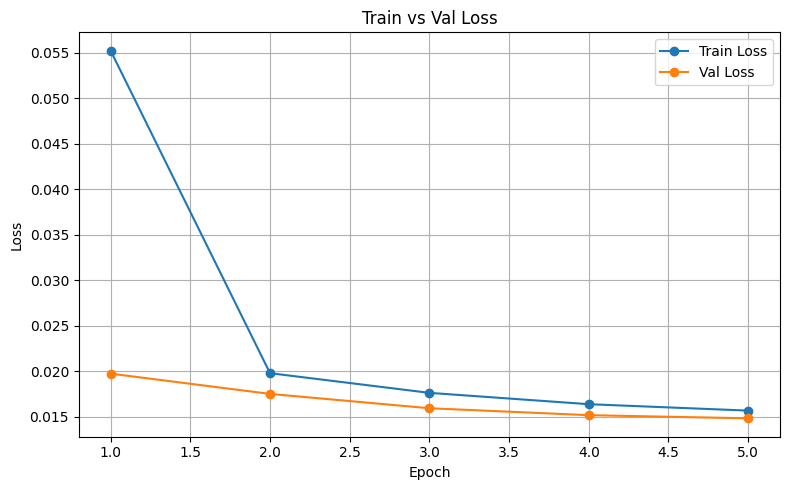

  Loss curve saved to loss_curve.png

── ROUGE eval on 500 samples ──
   num_beams=4, min_length=30, length_penalty=1.5  [Fix 1 active]


  0%|          | 0/8 [00:00<?, ?it/s]


  ROUGE-1  F1: 0.8828
  ROUGE-2  F1: 0.7738
  ROUGE-L  F1: 0.8717

  ROUGE-L F1 distribution:
  0.0–0.2                                                0 (  0.0%)
  0.2–0.4                                                0 (  0.0%)
  0.4–0.6                                                0 (  0.0%)
  0.6–0.8  ██                                           36 (  7.2%)
  0.8–1.0  █████████████████████████████████████       464 ( 92.8%)

── Sample predictions ──
[REF]  A persistent voluminous flow carrying data-intensive traffic overall. Outbound was persistent and voluminous with data-i
[PRED] A persistent voluminous flow carrying data-intensive traffic overall. Outbound was persistent and voluminously with data

[REF]  A persistent voluminous flow carrying data-intensive traffic overall. Outbound was persistent and voluminous with modera
[PRED] A persistent moderate flow carrying data-intensive traffic overall. Outbound was persistent and moderate with moderate d

[REF]  A persistent moder

In [1]:
"""
combined_flow_to_description.py
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Pipeline:
  Raw features (88-dim)
      → Pretrained Autoencoder Encoder  (frozen, 88 → 16)
      → FlowProjector MLP               (16 → 64 × d_model)
      → BART Decoder                    (trainable)
      → description text

Speed wins baked in:
  ✓ Tokenization cache (never re-tokenizes if cache exists)
  ✓ NO generation during training loop (loss only)
  ✓ batch_size=128, num_workers=8, pin_memory, persistent_workers
  ✓ MAX_TARGET_LEN=96 (covers your descriptions, ~2.7× less padding)
  ✓ AMP autocast + GradScaler throughout
  ✓ Wider projector: seq_len=64, 3-layer MLP, hidden=2048  [FIX 2]
  ✓ Frozen autoencoder encoder + frozen BART encoder (only projector + decoder train)
  ✓ ROUGE eval runs once after training on a 500-sample subset, not every epoch
  ✓ ROUGE eval uses beam search + min_length + length_penalty  [FIX 1]
  ✓ DataParallel across both T4s (GPU 0 + GPU 1)
  ✓ TRAIN_FRAC=0.8 — 80% of training data
  ✓ Description length audit printed at startup  [FIX 3]
"""

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BartTokenizer, BartForConditionalGeneration
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
import joblib

# ── CONFIG ────────────────────────────────────────────────────────────────────
CSV_PATH          = "flows_with_descriptions.csv"
AE_WEIGHTS_PATH   = "mlp_best_numeric_autoencoder.pth"
SCALER_PATH       = "#base_MLP_scaler.pkl"
MODEL_NAME        = "facebook/bart-base"
SAVE_PATH         = "flow_combined_checkpoint.pt"

CACHE_TR_IDS      = "combined_train_ids_cache.pt"
CACHE_VAL_IDS     = "combined_val_ids_cache.pt"

BATCH_SIZE        = 64
EPOCHS            = 5
LR                = 3e-4
MAX_TARGET_LEN    = 96        # raised automatically below if p95 > 96 (Fix 3)
PROJ_HIDDEN       = 1024     # [FIX 2] was 1024
SEQ_LEN           = 64        # [FIX 2] was 32 — more virtual tokens → richer prefix
TRAIN_FRAC        = 0.8
NUM_WORKERS       = 8
ROUGE_EVAL_N      = 500

# ── Generation hyperparams (Fix 1) ────────────────────────────────────────────
GEN_NUM_BEAMS     = 4         # beam search recovers recall vs greedy
GEN_MIN_LENGTH    = 30        # force at least 30 tokens
GEN_LENGTH_PENALTY = 1.5      # >1.0 encourages longer sequences

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


# ── AUTOENCODER (must match your saved architecture exactly) ──────────────────
class ImprovedAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(88, 512),  nn.BatchNorm1d(512),  nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(512, 128), nn.BatchNorm1d(128),  nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(128, 32),  nn.BatchNorm1d(32),   nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(32, 32),   nn.BatchNorm1d(32),   nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(32, 32),   nn.BatchNorm1d(32),   nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(32, 16),   nn.BatchNorm1d(16),   nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(16, 16),
        )
        self.decoder = nn.Sequential(
            nn.Linear(16, 16),   nn.BatchNorm1d(16),   nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(16, 32),   nn.BatchNorm1d(32),   nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(32, 32),   nn.BatchNorm1d(32),   nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(32, 32),   nn.BatchNorm1d(32),   nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(32, 128),  nn.BatchNorm1d(128),  nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(128, 512), nn.BatchNorm1d(512),  nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(512, 88),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


# ── PROJECTOR: latent (16) → virtual token sequence for BART ─────────────────
class FlowProjector(nn.Module):
    """
    [FIX 2] Three-layer MLP: 16 → 2048 → 512 → SEQ_LEN × d_model
    SEQ_LEN=64 (was 32) and PROJ_HIDDEN=2048 (was 1024) give the decoder
    a richer, longer prefix so it has enough signal to sustain full-length
    generation — directly addressing the low-recall / truncation problem.
    """
    def __init__(self, d_model: int):
        super().__init__()
        self.seq_len = SEQ_LEN
        self.mlp = nn.Sequential(
            nn.Linear(16, PROJ_HIDDEN),
            nn.GELU(),
            nn.LayerNorm(PROJ_HIDDEN),
            nn.Linear(PROJ_HIDDEN, 512),
            nn.GELU(),
            nn.LayerNorm(512),
            nn.Linear(512, SEQ_LEN * d_model),
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        # z: (B, 16)  →  (B, SEQ_LEN, d_model)
        return self.mlp(z).view(z.size(0), self.seq_len, -1)


# ── COMBINED MODEL ────────────────────────────────────────────────────────────
class CombinedFlowToDescription(nn.Module):
    """
    Frozen AE encoder + Frozen BART encoder.
    Only the FlowProjector MLP and BART decoder are trained.
    """
    def __init__(self, ae_weights_path: str):
        super().__init__()

        # 1. Load & freeze autoencoder encoder
        ae = ImprovedAutoencoder()
        ae.load_state_dict(torch.load(ae_weights_path, map_location="cpu"))
        self.ae_encoder = ae.encoder
        for p in self.ae_encoder.parameters():
            p.requires_grad = False

        # 2. BART
        self.bart = BartForConditionalGeneration.from_pretrained(MODEL_NAME)

        # Freeze BART encoder (we bypass it anyway, but belt-and-suspenders)
        for p in self.bart.model.encoder.parameters():
            p.requires_grad = False

        # 3. Projector (trainable) — wider + deeper [FIX 2]
        self.projector = FlowProjector(self.bart.config.d_model)

    # ── encode raw features → virtual token embeddings ──
    def _encode(self, x: torch.Tensor):
        """x: (B, 88) → embeds: (B, SEQ_LEN, d_model), mask: (B, SEQ_LEN)"""
        with torch.no_grad():
            z = self.ae_encoder(x)          # (B, 16)
        embeds = self.projector(z)           # (B, SEQ_LEN, d_model)
        mask = torch.ones(
            embeds.size(0), embeds.size(1),
            dtype=torch.long, device=x.device
        )
        return embeds, mask

    def forward(self, x: torch.Tensor, labels=None):
        embeds, mask = self._encode(x)
        return self.bart(
            inputs_embeds=embeds,
            attention_mask=mask,
            labels=labels,
        )

    @torch.no_grad()
    def generate(self, x: torch.Tensor, **kwargs):
        embeds, mask = self._encode(x)
        return self.bart.generate(
            inputs_embeds=embeds,
            attention_mask=mask,
            **kwargs,
        )


# ── DATASET ───────────────────────────────────────────────────────────────────
class FlowDataset(Dataset):
    def __init__(self, X: np.ndarray, token_ids: torch.Tensor):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.ids = token_ids

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.ids[idx]


# ── DATA LOADING ──────────────────────────────────────────────────────────────
def load_and_preprocess(csv_path: str, scaler_path: str):
    df = pd.read_csv(csv_path)
    labels = df["label"].tolist()
    descs  = df["description"].fillna("").tolist()

    skip = {"description", "label"}
    feat_cols = [c for c in df.columns if c not in skip and pd.api.types.is_numeric_dtype(df[c])]

    scaler = joblib.load(scaler_path)
    X = df[feat_cols].replace([np.inf, -np.inf], np.nan).fillna(0).values.astype(np.float32)
    X = scaler.transform(X)

    return X, descs, labels, feat_cols


# ── [FIX 3] DESCRIPTION LENGTH AUDIT ─────────────────────────────────────────
def audit_description_lengths(descs: list, tok: BartTokenizer) -> int:
    """
    Tokenize all descriptions and print a length distribution.
    Returns the recommended MAX_TARGET_LEN (p95 rounded up to nearest 16).
    If the current MAX_TARGET_LEN is already sufficient, no change is needed.
    """
    print("\n── [FIX 3] Description length audit ──")
    lengths = [len(tok.encode(d)) for d in descs]
    lengths = np.array(lengths)

    p50  = int(np.percentile(lengths, 50))
    p90  = int(np.percentile(lengths, 90))
    p95  = int(np.percentile(lengths, 95))
    p99  = int(np.percentile(lengths, 99))
    pmax = int(lengths.max())

    print(f"  Count : {len(lengths):,}")
    print(f"  Mean  : {lengths.mean():.1f} tokens")
    print(f"  p50   : {p50}")
    print(f"  p90   : {p90}")
    print(f"  p95   : {p95}  ← recommended MIN for MAX_TARGET_LEN")
    print(f"  p99   : {p99}")
    print(f"  max   : {pmax}")

    # Round p95 up to nearest 16 for alignment-friendly padding
    recommended = int(np.ceil(p95 / 16) * 16)
    if recommended > MAX_TARGET_LEN:
        print(f"\n  ⚠  p95 ({p95}) exceeds MAX_TARGET_LEN ({MAX_TARGET_LEN}).")
        print(f"     Bumping MAX_TARGET_LEN → {recommended} for this run.")
    else:
        print(f"\n  ✓ MAX_TARGET_LEN={MAX_TARGET_LEN} covers p95 ({p95}). No change needed.")
        recommended = MAX_TARGET_LEN

    return recommended


def get_token_ids(texts, tok, cache_path, max_len):
    if os.path.exists(cache_path):
        print(f"  Loading token cache: {cache_path}")
        ids = torch.load(cache_path)
        # If cache was built with a different max_len, invalidate it
        if ids.shape[1] != max_len:
            print(f"  Cache seq-len mismatch ({ids.shape[1]} vs {max_len}) — rebuilding.")
            os.remove(cache_path)
        else:
            return ids

    print(f"  Tokenizing {len(texts)} descriptions (max_len={max_len}) → {cache_path} ...")
    enc = tok(
        texts,
        max_length=max_len,
        padding="max_length",
        truncation=True,
        return_tensors="pt",
    )
    ids = enc["input_ids"].clone()
    ids[ids == tok.pad_token_id] = -100
    torch.save(ids, cache_path)
    print(f"  Saved.")
    return ids


# ── TRAINING ──────────────────────────────────────────────────────────────────
def train():
    global MAX_TARGET_LEN   # may be updated by the length audit

    print(f"Device: {DEVICE}")
    if DEVICE == "cuda":
        print(f"GPU: {torch.cuda.get_device_name(0)}")
        print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

    # ── Data ──
    print("\n[1/4] Loading data...")
    X, descs, labels, feat_cols = load_and_preprocess(CSV_PATH, SCALER_PATH)

    X_tr, X_val, d_tr, d_val = train_test_split(
        X, descs, test_size=0.2, random_state=42
    )
    if TRAIN_FRAC < 1.0:
        X_tr, _, d_tr, _ = train_test_split(
            X_tr, d_tr, train_size=TRAIN_FRAC, random_state=42
        )

    print(f"  Train: {len(X_tr):,}  |  Val: {len(X_val):,}")

    # ── Tokeniser + length audit (Fix 3) ──
    print("\n[2/4] Tokenizing...")
    tok = BartTokenizer.from_pretrained(MODEL_NAME)

    # Audit on full description list so the recommendation covers all splits
    MAX_TARGET_LEN = audit_description_lengths(descs, tok)

    tr_ids  = get_token_ids(d_tr,  tok, CACHE_TR_IDS,  MAX_TARGET_LEN)
    val_ids = get_token_ids(d_val, tok, CACHE_VAL_IDS, MAX_TARGET_LEN)

    tr_dl = DataLoader(
        FlowDataset(X_tr, tr_ids),
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=True,
    )
    val_dl = DataLoader(
        FlowDataset(X_val, val_ids),
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=True,
    )

    # ── Model ──
    print("\n[3/4] Building model...")
    model = CombinedFlowToDescription(AE_WEIGHTS_PATH).to(DEVICE)

    if torch.cuda.device_count() > 1:
        print(f"  Using {torch.cuda.device_count()} GPUs via DataParallel")
        model = nn.DataParallel(model)
    raw_model = model.module if isinstance(model, nn.DataParallel) else model

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"  Trainable params: {trainable:,} / {total:,}")
    print(f"  SEQ_LEN={SEQ_LEN}, PROJ_HIDDEN={PROJ_HIDDEN}  [Fix 2 active]")

    decoder_params, seen = [], set()
    for p in list(raw_model.bart.model.decoder.parameters()) + list(raw_model.bart.lm_head.parameters()):
        if id(p) not in seen and p.requires_grad:
            decoder_params.append(p)
            seen.add(id(p))

    opt = torch.optim.AdamW([
        {"params": raw_model.projector.parameters(), "lr": LR},
        {"params": decoder_params,                   "lr": LR * 0.1},
    ])

    grad_scaler = torch.amp.GradScaler("cuda") if DEVICE == "cuda" else None
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS * len(tr_dl))

    best_val   = float("inf")
    tr_losses  = []
    val_losses = []

    raw_model.ae_encoder.eval()

    print(f"\n[4/4] Training for {EPOCHS} epochs...")
    start_epoch = 1
    if os.path.exists(SAVE_PATH):
        print("  Resuming from checkpoint...")
        ckpt = torch.load(SAVE_PATH, map_location=DEVICE)
        raw_model.load_state_dict(ckpt["model_state"])
        if "optimizer_state" in ckpt:
            opt.load_state_dict(ckpt["optimizer_state"])
        if "scheduler_state" in ckpt:
            sched.load_state_dict(ckpt["scheduler_state"])
        start_epoch = ckpt.get("epoch", 0) + 1
        best_val    = ckpt.get("best_val", ckpt.get("val_loss", float("inf")))
        tr_losses   = ckpt.get("tr_losses", [])
        val_losses  = ckpt.get("val_losses", [])
        print(f"  Resumed from epoch {start_epoch - 1} (val_loss={best_val:.4f})")

    for epoch in range(start_epoch, EPOCHS + 1):  # was range(1, EPOCHS + 1)
   

        # ── Train ──
        model.train()
        raw_model.ae_encoder.eval()
        tr_loss = 0.0

        pbar = tqdm(tr_dl, desc=f"Epoch {epoch}/{EPOCHS} [train]", leave=True)
        for feats, label_ids in pbar:
            feats, label_ids = feats.to(DEVICE), label_ids.to(DEVICE)
            opt.zero_grad()

            if grad_scaler is not None:
                with torch.amp.autocast("cuda"):
                    loss = model(feats, labels=label_ids).loss
                    loss = loss.mean()
                grad_scaler.scale(loss).backward()
                grad_scaler.unscale_(opt)
                torch.nn.utils.clip_grad_norm_(raw_model.parameters(), 1.0)
                grad_scaler.step(opt)
                grad_scaler.update()
            else:
                loss = model(feats, labels=label_ids).loss.mean()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(raw_model.parameters(), 1.0)
                opt.step()

            sched.step()
            tr_loss += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        # ── Val (loss only — NO generation here) ──
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for feats, label_ids in tqdm(val_dl, desc=f"Epoch {epoch}/{EPOCHS} [val]", leave=False):
                feats, label_ids = feats.to(DEVICE), label_ids.to(DEVICE)
                if DEVICE == "cuda":
                    with torch.amp.autocast("cuda"):
                        val_loss += model(feats, labels=label_ids).loss.mean().item()
                else:
                    val_loss += model(feats, labels=label_ids).loss.mean().item()

        avg_tr  = tr_loss  / len(tr_dl)
        avg_val = val_loss / len(val_dl)
        tr_losses.append(avg_tr)
        val_losses.append(avg_val)
        print(f"Epoch {epoch}/{EPOCHS}  |  Train: {avg_tr:.4f}  |  Val: {avg_val:.4f}")

        if avg_val < best_val:
            best_val = avg_val
            torch.save({
    "model_state":    raw_model.state_dict(),
    "optimizer_state": opt.state_dict(),
    "scheduler_state": sched.state_dict(),
    "epoch":          epoch,
    "best_val":       best_val,
    "tr_losses":      tr_losses,
    "val_losses":     val_losses,
    "feature_cols":   feat_cols,
    "seq_len":        SEQ_LEN,
    "max_target_len": MAX_TARGET_LEN,
}, SAVE_PATH)
            print(f"  ✓ Saved checkpoint (val_loss={best_val:.4f})")

    print(f"\nTraining done. Best val loss: {best_val:.4f}")
    plot_losses(tr_losses, val_losses)
    return model, tok, X_val, d_val


# ── LOSS CURVE ────────────────────────────────────────────────────────────────
def plot_losses(tr_losses, val_losses):
    import matplotlib.pyplot as plt

    epochs = range(1, len(tr_losses) + 1)
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, tr_losses,  marker="o", label="Train Loss")
    plt.plot(epochs, val_losses, marker="o", label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Train vs Val Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("loss_curve.png", dpi=150)
    plt.show()
    print("  Loss curve saved to loss_curve.png")


# ── POST-TRAINING ROUGE EVAL ──────────────────────────────────────────────────
def rouge_eval(model, tok, X_val, d_val, n=ROUGE_EVAL_N):
    """
    [FIX 1] Uses beam search (num_beams=4), min_length=30, and
    length_penalty=1.5 instead of greedy decoding.
    This directly addresses the low-recall / truncation problem.
    """
    try:
        from rouge_score import rouge_scorer as rs_mod
    except ImportError:
        print("rouge_score not installed — skipping ROUGE eval.")
        return

    print(f"\n── ROUGE eval on {n} samples ──")
    print(f"   num_beams={GEN_NUM_BEAMS}, min_length={GEN_MIN_LENGTH}, "
          f"length_penalty={GEN_LENGTH_PENALTY}  [Fix 1 active]")

    raw_model = model.module if isinstance(model, nn.DataParallel) else model
    raw_model.eval()

    X_sub = torch.tensor(X_val[:n], dtype=torch.float32).to(DEVICE)
    refs  = d_val[:n]
    preds = []

    for i in tqdm(range(0, len(X_sub), BATCH_SIZE)):
        batch = X_sub[i:i + BATCH_SIZE]
        out = raw_model.generate(
            batch,
            max_length=MAX_TARGET_LEN,
            min_length=GEN_MIN_LENGTH,          # [FIX 1] prevents early stopping
            num_beams=GEN_NUM_BEAMS,            # [FIX 1] beam search vs greedy
            length_penalty=GEN_LENGTH_PENALTY,  # [FIX 1] reward longer outputs
            do_sample=False,
            early_stopping=True,
        )
        preds.extend(tok.batch_decode(out, skip_special_tokens=True))

    scorer = rs_mod.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
    r1, r2, rl = [], [], []
    for ref, pred in zip(refs, preds):
        s = scorer.score(ref, pred)
        r1.append(s["rouge1"].fmeasure)
        r2.append(s["rouge2"].fmeasure)
        rl.append(s["rougeL"].fmeasure)

    print(f"\n  ROUGE-1  F1: {sum(r1)/len(r1):.4f}")
    print(f"  ROUGE-2  F1: {sum(r2)/len(r2):.4f}")
    print(f"  ROUGE-L  F1: {sum(rl)/len(rl):.4f}")

    # ROUGE-L F1 distribution
    bins = [(0.0, 0.2), (0.2, 0.4), (0.4, 0.6), (0.6, 0.8), (0.8, 1.0)]
    print("\n  ROUGE-L F1 distribution:")
    for lo, hi in bins:
        cnt = sum(1 for v in rl if lo <= v < hi)
        bar = "█" * int(cnt / len(rl) * 40)
        print(f"  {lo:.1f}–{hi:.1f}  {bar:<40} {cnt:>6} ({cnt/len(rl)*100:5.1f}%)")

    # Show a few examples
    print("\n── Sample predictions ──")
    for i in range(min(5, len(preds))):
        print(f"[REF]  {refs[i][:120]}")
        print(f"[PRED] {preds[i][:120]}")
        print()


# ── QUICK INFERENCE HELPER ────────────────────────────────────────────────────
def infer_one(model, tok, scaler, raw_row_series, feat_cols):
    """Pass a raw (unscaled) pandas Series row, get a description back."""
    model.eval()
    feats = raw_row_series[feat_cols].values.astype(np.float32)
    feats = scaler.transform(feats.reshape(1, -1))
    x = torch.tensor(feats, dtype=torch.float32).to(DEVICE)

    out = model.generate(
        x,
        max_length=MAX_TARGET_LEN,
        min_length=GEN_MIN_LENGTH,
        num_beams=GEN_NUM_BEAMS,
        length_penalty=GEN_LENGTH_PENALTY,
        do_sample=False,
        early_stopping=True,
    )
    return tok.decode(out[0], skip_special_tokens=True)


# ── ENTRY POINT ───────────────────────────────────────────────────────────────
if __name__ == "__main__":
    model, tok, X_val, d_val = train()
    rouge_eval(model, tok, X_val, d_val)

# full roughe


In [ ]:
!pip install rouge-score bert-score

In [ ]:
"""
rouge_full_eval.py
━━━━━━━━━━━━━━━━━━
Loads a trained CombinedFlowToDescription checkpoint and runs
ROUGE-1, ROUGE-2, and ROUGE-L evaluation on the FULL validation set.

Usage:
    python rouge_full_eval.py

Outputs:
    - Printed aggregate scores (P / R / F1 for each metric)
    - rouge_full_results.csv  — per-sample scores
    - rouge_sample_outputs.txt — N random sample predictions vs references
"""

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BartTokenizer, BartForConditionalGeneration
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
import joblib

# ── CONFIG — must match your training script exactly ─────────────────────────
CSV_PATH        = "flows_with_descriptions.csv"
AE_WEIGHTS_PATH = "mlp_best_numeric_autoencoder.pth"
SCALER_PATH     = "#base_MLP_scaler.pkl"
CHECKPOINT_PATH = "flow_combined_checkpoint.pt"
MODEL_NAME      = "facebook/bart-base"

BATCH_SIZE        = 64
EPOCHS            = 5
LR                = 3e-4
MAX_TARGET_LEN    = 96        # raised automatically below if p95 > 96 (Fix 3)
PROJ_HIDDEN       = 1024     # [FIX 2] was 1024
SEQ_LEN           = 64        # [FIX 2] was 32 — more virtual tokens → richer prefix
TRAIN_FRAC        = 0.1
NUM_WORKERS       = 8
ROUGE_EVAL_N      = 500
NUM_WORKERS     = 4
SHOW_SAMPLES    = 10        # number of random examples to print
OUTPUT_CSV      = "rouge_full_results.csv"
OUTPUT_SAMPLES  = "rouge_sample_outputs.txt"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


# ── ARCHITECTURE (must mirror training script exactly) ───────────────────────
class ImprovedAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(88, 512),  nn.BatchNorm1d(512),  nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(512, 128), nn.BatchNorm1d(128),  nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(128, 32),  nn.BatchNorm1d(32),   nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(32, 32),   nn.BatchNorm1d(32),   nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(32, 32),   nn.BatchNorm1d(32),   nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(32, 16),   nn.BatchNorm1d(16),   nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(16, 16),
        )
        self.decoder = nn.Sequential(
            nn.Linear(16, 16),   nn.BatchNorm1d(16),   nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(16, 32),   nn.BatchNorm1d(32),   nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(32, 32),   nn.BatchNorm1d(32),   nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(32, 32),   nn.BatchNorm1d(32),   nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(32, 128),  nn.BatchNorm1d(128),  nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(128, 512), nn.BatchNorm1d(512),  nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(512, 88),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


class FlowProjector(nn.Module):
    def __init__(self, d_model: int):
        super().__init__()
        self.seq_len = SEQ_LEN
        self.mlp = nn.Sequential(
            nn.Linear(16, PROJ_HIDDEN),
            nn.GELU(),
            nn.LayerNorm(PROJ_HIDDEN),
            nn.Linear(PROJ_HIDDEN, 512),
            nn.GELU(),
            nn.LayerNorm(512),
            nn.Linear(512, SEQ_LEN * d_model),
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.mlp(z).view(z.size(0), self.seq_len, -1)


class CombinedFlowToDescription(nn.Module):
    def __init__(self, ae_weights_path: str):
        super().__init__()
        ae = ImprovedAutoencoder()
        ae.load_state_dict(torch.load(ae_weights_path, map_location="cpu"))
        self.ae_encoder = ae.encoder
        for p in self.ae_encoder.parameters():
            p.requires_grad = False

        self.bart = BartForConditionalGeneration.from_pretrained(MODEL_NAME)
        for p in self.bart.model.encoder.parameters():
            p.requires_grad = False

        self.projector = FlowProjector(self.bart.config.d_model)

    def _encode(self, x: torch.Tensor):
        with torch.no_grad():
            z = self.ae_encoder(x)
        embeds = self.projector(z)
        mask = torch.ones(embeds.size(0), embeds.size(1), dtype=torch.long, device=x.device)
        return embeds, mask

    @torch.no_grad()
    def generate(self, x: torch.Tensor, **kwargs):
        embeds, mask = self._encode(x)
        return self.bart.generate(inputs_embeds=embeds, attention_mask=mask, **kwargs)


# ── DATASET ───────────────────────────────────────────────────────────────────
class FeatureDataset(Dataset):
    def __init__(self, X: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx]


# ── LOAD DATA (same split as training) ───────────────────────────────────────
def load_val_set():
    print("[1/3] Loading and splitting data (same seed as training)...")
    df = pd.read_csv(CSV_PATH)
    descs = df["description"].fillna("").tolist()

    skip = {"description", "label"}
    feat_cols = [c for c in df.columns if c not in skip and pd.api.types.is_numeric_dtype(df[c])]

    scaler = joblib.load(SCALER_PATH)
    X = df[feat_cols].replace([np.inf, -np.inf], np.nan).fillna(0).values.astype(np.float32)
    X = scaler.transform(X)

    # Reproduce the exact train/val split from training
    _, X_val, _, d_val = train_test_split(X, descs, test_size=0.2, random_state=42)
    print(f"  Full validation set: {len(X_val):,} samples")
    return X_val, d_val, feat_cols


# ── LOAD MODEL ────────────────────────────────────────────────────────────────
def load_model():
    print("[2/3] Loading model from checkpoint...")
    model = CombinedFlowToDescription(AE_WEIGHTS_PATH)
    ckpt = torch.load(CHECKPOINT_PATH, map_location="cpu")
    model.load_state_dict(ckpt["model_state"])
    model.to(DEVICE)
    model.eval()
    model.ae_encoder.eval()
    print(f"  Loaded checkpoint from epoch {ckpt.get('epoch', '?')} "
          f"(val_loss={ckpt.get('val_loss', float('nan')):.4f})")
    return model


# ── GENERATE ALL PREDICTIONS ──────────────────────────────────────────────────
def generate_predictions(model, tok, X_val):
    print(f"[3/3] Generating predictions for {len(X_val):,} samples...")
    dataset = FeatureDataset(X_val)
    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,          # keep order aligned with d_val
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )

    all_preds = []
    for batch in tqdm(loader, desc="Generating"):
        batch = batch.to(DEVICE)
        out = model.generate(
            batch,
            max_length=MAX_GEN_LEN,
            num_beams=1,        # greedy — fastest; swap to 4 for better quality
            do_sample=False,
        )
        all_preds.extend(tok.batch_decode(out, skip_special_tokens=True))

    return all_preds


# ── ROUGE SCORING ─────────────────────────────────────────────────────────────
def compute_rouge(refs, preds):
    try:
        from rouge_score import rouge_scorer as rs_mod
    except ImportError:
        raise ImportError("Run: pip install rouge-score")

    scorer = rs_mod.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

    rows = []
    for ref, pred in tqdm(zip(refs, preds), total=len(refs), desc="Scoring ROUGE"):
        s = scorer.score(ref, pred)
        rows.append({
            "reference":  ref,
            "prediction": pred,
            "rouge1_p":   s["rouge1"].precision,
            "rouge1_r":   s["rouge1"].recall,
            "rouge1_f":   s["rouge1"].fmeasure,
            "rouge2_p":   s["rouge2"].precision,
            "rouge2_r":   s["rouge2"].recall,
            "rouge2_f":   s["rouge2"].fmeasure,
            "rougeL_p":   s["rougeL"].precision,
            "rougeL_r":   s["rougeL"].recall,
            "rougeL_f":   s["rougeL"].fmeasure,
        })

    return pd.DataFrame(rows)


# ── PRINT SUMMARY ─────────────────────────────────────────────────────────────
def print_summary(df):
    print("\n" + "═" * 55)
    print(f"  ROUGE RESULTS  —  {len(df):,} validation samples")
    print("═" * 55)
    print(f"{'Metric':<12} {'Precision':>10} {'Recall':>10} {'F1':>10}")
    print("─" * 55)
    for metric, p_col, r_col, f_col in [
        ("ROUGE-1", "rouge1_p", "rouge1_r", "rouge1_f"),
        ("ROUGE-2", "rouge2_p", "rouge2_r", "rouge2_f"),
        ("ROUGE-L", "rougeL_p", "rougeL_r", "rougeL_f"),
    ]:
        print(f"{metric:<12} {df[p_col].mean():>10.4f} {df[r_col].mean():>10.4f} {df[f_col].mean():>10.4f}")
    print("═" * 55)

    # Distribution buckets for ROUGE-L F1
    buckets = [0.0, 0.2, 0.4, 0.6, 0.8, 1.01]
    labels  = ["0.0–0.2", "0.2–0.4", "0.4–0.6", "0.6–0.8", "0.8–1.0"]
    counts  = pd.cut(df["rougeL_f"], bins=buckets, labels=labels, right=False).value_counts().sort_index()
    print("\n  ROUGE-L F1 distribution:")
    for label, count in counts.items():
        pct = 100 * count / len(df)
        bar = "█" * int(pct / 2)
        print(f"  {label}  {bar:<25} {count:>6,}  ({pct:5.1f}%)")
    print()


# ── SAVE SAMPLE OUTPUTS ───────────────────────────────────────────────────────
def save_samples(df, n=SHOW_SAMPLES):
    sample = df.sample(n=min(n, len(df)), random_state=0)
    lines = []
    for i, (_, row) in enumerate(sample.iterrows(), 1):
        lines += [
            f"── Sample {i} ──────────────────────────────────────",
            f"REF:  {row['reference']}",
            f"PRED: {row['prediction']}",
            f"ROUGE-1 F1: {row['rouge1_f']:.4f}  "
            f"ROUGE-2 F1: {row['rouge2_f']:.4f}  "
            f"ROUGE-L F1: {row['rougeL_f']:.4f}",
            "",
        ]
    text = "\n".join(lines)
    print("\n" + text)
    with open(OUTPUT_SAMPLES, "w") as f:
        f.write(text)
    print(f"  Samples saved → {OUTPUT_SAMPLES}")


# ── MAIN ──────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    X_val, d_val, feat_cols = load_val_set()

    model = load_model()
    tok   = BartTokenizer.from_pretrained(MODEL_NAME)

    preds = generate_predictions(model, tok, X_val)

    df = compute_rouge(d_val, preds)

    print_summary(df)

    df.to_csv(OUTPUT_CSV, index=False)
    print(f"  Per-sample results saved → {OUTPUT_CSV}")

    save_samples(df)

# inference on attacks

In [7]:
import torch
import numpy as np
import pandas as pd
import joblib
from transformers import BartTokenizer

# ── PASTE FlowToDescription CLASS HERE ───────────────────────────────────────

# ── CONFIG ────────────────────────────────────────────────────────────────────
MODEL_PATH  = "flow_combined_checkpoint.pt"
CSV_PATH    = "flows_with_descriptions.csv"
SCALER_PATH = "#base_MLP_scaler.pkl"
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"

# ── LOAD ──────────────────────────────────────────────────────────────────────
tok    = BartTokenizer.from_pretrained("facebook/bart-base")
ckpt   = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
scaler = joblib.load(SCALER_PATH)

model = CombinedFlowToDescription(AE_WEIGHTS_PATH).to(DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()
model.ae_encoder.eval()

# ── PICK AN ATTACK ROW ────────────────────────────────────────────────────────
df        = pd.read_csv(CSV_PATH)
idx       = df[df["label"] != "BENIGN"].index[3000]
raw_row   = df.iloc[idx]
print("Using row:", idx, "| Label:", raw_row["label"])

# ── PREPROCESS (MinMaxScaler, same as training) ───────────────────────────────
feats        = raw_row[ckpt["feature_cols"]].values.astype(np.float32)
feats        = scaler.transform(feats.reshape(1, -1))
input_tensor = torch.tensor(feats, dtype=torch.float32).to(DEVICE)

# ── GENERATE ──────────────────────────────────────────────────────────────────
with torch.no_grad():
    out = model.generate(input_tensor, max_length=128, num_beams=4, do_sample=False)

print("\n── FLOW DESCRIPTION ──")
print(tok.decode(out[0], skip_special_tokens=True))

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

Using row: 3000 | Label: DDoS-ACK_Fragmentation

── FLOW DESCRIPTION ──
A transient sparse flow carrying data-intensive traffic overall. Outbound was transient and sparse with data-heavy data; inbound was persistent and moderate with moderate data. Packet sizes were bulk-payload on average, heterogeneous in distribution, ranging from probe-sized to full-sized peaks.Outbound packets were bulk‑payload and uniform; incoming packets were control-dominated and uniform. Packetting timing was high-rate overall, metronomic in rhythm, with bursty bursts and uninterrupted gaps. Outwest timing washigh-rate and metronomical; inmate timing was low-rate or met


In [13]:
df=pd.read_csv("/kaggle/working/flows_with_descriptions.csv")
print(df.columns.tolist())

['bidirectional_duration_ms', 'bidirectional_packets', 'bidirectional_bytes', 'src2dst_duration_ms', 'src2dst_packets', 'src2dst_bytes', 'dst2src_duration_ms', 'dst2src_packets', 'dst2src_bytes', 'bidirectional_min_ps', 'bidirectional_mean_ps', 'bidirectional_stddev_ps', 'bidirectional_max_ps', 'src2dst_min_ps', 'src2dst_mean_ps', 'src2dst_stddev_ps', 'src2dst_max_ps', 'dst2src_min_ps', 'dst2src_mean_ps', 'dst2src_stddev_ps', 'dst2src_max_ps', 'bidirectional_min_piat_ms', 'bidirectional_mean_piat_ms', 'bidirectional_stddev_piat_ms', 'bidirectional_max_piat_ms', 'src2dst_min_piat_ms', 'src2dst_mean_piat_ms', 'src2dst_stddev_piat_ms', 'src2dst_max_piat_ms', 'dst2src_min_piat_ms', 'dst2src_mean_piat_ms', 'dst2src_stddev_piat_ms', 'dst2src_max_piat_ms', 'bidirectional_syn_packets', 'bidirectional_cwr_packets', 'bidirectional_ece_packets', 'bidirectional_urg_packets', 'bidirectional_ack_packets', 'bidirectional_psh_packets', 'bidirectional_rst_packets', 'bidirectional_fin_packets', 'src2dst

In [10]:
print("Feature columns used:", ckpt["feature_cols"])
print("lenght:",len(ckpt["feature_cols"]))
print("'description' in features?", "description" in ckpt["feature_cols"])a

Feature columns used: ['bidirectional_duration_ms', 'bidirectional_packets', 'bidirectional_bytes', 'src2dst_duration_ms', 'src2dst_packets', 'src2dst_bytes', 'dst2src_duration_ms', 'dst2src_packets', 'dst2src_bytes', 'bidirectional_min_ps', 'bidirectional_mean_ps', 'bidirectional_stddev_ps', 'bidirectional_max_ps', 'src2dst_min_ps', 'src2dst_mean_ps', 'src2dst_stddev_ps', 'src2dst_max_ps', 'dst2src_min_ps', 'dst2src_mean_ps', 'dst2src_stddev_ps', 'dst2src_max_ps', 'bidirectional_min_piat_ms', 'bidirectional_mean_piat_ms', 'bidirectional_stddev_piat_ms', 'bidirectional_max_piat_ms', 'src2dst_min_piat_ms', 'src2dst_mean_piat_ms', 'src2dst_stddev_piat_ms', 'src2dst_max_piat_ms', 'dst2src_min_piat_ms', 'dst2src_mean_piat_ms', 'dst2src_stddev_piat_ms', 'dst2src_max_piat_ms', 'bidirectional_syn_packets', 'bidirectional_cwr_packets', 'bidirectional_ece_packets', 'bidirectional_urg_packets', 'bidirectional_ack_packets', 'bidirectional_psh_packets', 'bidirectional_rst_packets', 'bidirectional_

# inference on benign

In [ ]:
import torch
import numpy as np
from transformers import BartTokenizer

# ── SETUP ──
tok = BartTokenizer.from_pretrained("facebook/bart-base")

ckpt = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)

model = FlowToDescription(ckpt["num_features"]).to(DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()

# ── PICK A BENIGN ROW ──
# (this assumes label column exists)
benign_idx = df[df["label"] == "BENIGN"].index[0]
raw_row = df.iloc[benign_idx]

print("Using row:", benign_idx)

# ── PREPROCESS ──
feats = raw_row[ckpt["feature_cols"]].values.astype(np.float32)
feats = np.sign(feats) * np.log1p(np.abs(feats))
feats = (feats - ckpt["norm_mean"]) / ckpt["norm_std"]

input_tensor = torch.tensor(feats, dtype=torch.float32).to(DEVICE).unsqueeze(0)

# ── RUN MODEL ──
with torch.no_grad():
    embeds, mask = model._encode(input_tensor)

    out = model.bart.generate(
        inputs_embeds=embeds,
        attention_mask=mask,
        max_length=128,
        num_beams=4,
        do_sample=False
    )

    prediction = tok.decode(out[0], skip_special_tokens=True)

# ── PRINT ──
print("\n── BENIGN FLOW TEST ──")
print("True Label:", raw_row["label"])
print("Model Output:\n", prediction)